# 🌍 Enhanced Climate Forecasting: Temperature & ET0

This notebook implements an **optimized** unified forecasting system for both **temperature** and **ET0 (evapotranspiration)**.

**Models (All Optimized):**
- ✨ **Prophet** - Facebook's time series forecaster (NEW)
- 🔧 **SARIMA** - Enhanced with exogenous variables
- 🧠 **LSTM** - Improved architecture with Bidirectional layers
- 📈 **Ridge Regression** - Polynomial features (upgraded from simple linear)

**✨ Google Colab Compatible** - Data automatically downloaded from Drive

**Improvements:**
1. Prophet added for automatic seasonality detection
2. SARIMA uses stricter parameter search
3. LSTM uses bidirectional layers + dropout
4. Linear upgraded to Ridge with polynomial features

## 🔧 Environment Setup (Colab Compatible)

In [1]:
# Detect environment (Colab or Local)
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("🌐 Running in Google Colab")
    print("📥 Installing required packages...")
    !pip install -q pmdarima statsmodels prophet scikit-learn
    print("✅ Packages installed!")
else:
    print("💻 Running locally")

🌐 Running in Google Colab
📥 Installing required packages...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 43.2 MB/s eta 0:00:00
✅ Packages installed!


## 📥 Data Download (Automatic from Google Drive)

In [2]:
import os

if IN_COLAB:
    # Download data from Google Drive
    print("📥 Downloading data from Google Drive...")

    # Extract file ID from share link
    file_id = "1TnlYsNUJq7--Kgj9AWGmhMAiW1N4ExbW"

    # Download using gdown
    !pip install -q gdown
    import gdown

    url = f"https://drive.google.com/uc?id={file_id}"
    output = "algiers_monthly_processed_v2.csv"
    gdown.download(url, output, quiet=False)

    data_path = output
    print(f"✅ Data downloaded to: {data_path}")

    # Create output directories
    os.makedirs('Results', exist_ok=True)
    os.makedirs('Predictions', exist_ok=True)
    print("✅ Output directories created")

else:
    # Local path
    from pathlib import Path
    data_path = Path('../Preprocessed_dataset/algiers_monthly_processed_v2.csv')
    print(f"💻 Using local data: {data_path}")

📥 Downloading data from Google Drive...


Downloading...
From: https://drive.google.com/uc?id=1TnlYsNUJq7--Kgj9AWGmhMAiW1N4ExbW
To: /content/algiers_monthly_processed_v2.csv
100%|██████████| 60.8k/60.8k [00:00<00:00, 32.7MB/s]

✅ Data downloaded to: algiers_monthly_processed_v2.csv
✅ Output directories created


## 1. Library Imports

In [3]:
# Core imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Time series models
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima
from prophet import Prophet

# Deep learning
try:
    from tensorflow import keras
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
    from sklearn.preprocessing import MinMaxScaler
    LSTM_AVAILABLE = True
    print("✅ TensorFlow available - Enhanced LSTM enabled")
except ImportError:
    LSTM_AVAILABLE = False
    print("⚠️ TensorFlow not available - LSTM will be skipped")

# Regression models
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline

# Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import linregress

# Plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print("✅ Libraries imported successfully")

✅ TensorFlow available - Enhanced LSTM enabled
✅ Libraries imported successfully


## 2. Load Data

In [4]:
# Load preprocessed data
df = pd.read_csv(data_path)
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')

print(f"✅ Loaded {len(df)} months of data")
print(f"   Date range: {df.index.min()} to {df.index.max()}")
print(f"\nColumns: {list(df.columns)[:8]}...")  # Show first 8 columns
df.head()

✅ Loaded 260 months of data
   Date range: 2002-01-01 00:00:00 to 2023-08-01 00:00:00

Columns: ['temperature_2m_mean', 'temperature_2m_max', 'temperature_2m_min', 'precipitation_sum', 'et0_fao_evapotranspiration', 'shortwave_radiation_sum', 'windspeed_10m_max', 'temp_anomaly']...


,temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum,et0_fao_evapotranspiration,shortwave_radiation_sum,windspeed_10m_max,temp_anomaly,water_balance,cumulative_water_balance,aridity_index,temp_rolling_12m,precip_rolling_12m,SPI_12_z,SPEI_12_z
date,,,,,,,,,,,,,,,
2002-01-01,9.935484,15.038710,6.025806,46.0,49.58,321.59,14.564516,-7.542253,-3.58,-3.58,1.075488,NaN,NaN,NaN,NaN
2002-02-01,11.146429,16.353571,6.753571,12.3,64.85,395.78,16.396429,-6.331308,-52.55,-56.13,5.229839,NaN,NaN,NaN,NaN
2002-03-01,13.435484,18.400000,9.148387,39.3,98.36,570.91,21.129032,-4.042253,-59.06,-115.19,2.496447,NaN,NaN,NaN,NaN
2002-04-01,14.866667,19.743333,10.046667,28.2,118.59,689.53,19.910000,-2.611070,-90.39,-205.58,4.190459,NaN,NaN,NaN,NaN
2002-05-01,18.858065,24.351613,13.329032,23.4,162.17,811.72,22.148387,1.380328,-138.77,-344.35,6.900851,NaN,NaN,NaN,NaN


In [5]:
# Configuration
VARIABLES = {
    'temperature': {
        'column': 'temperature_2m_mean',
        'label': 'Temperature (°C)',
        'color': '#E74C3C'
    },
    'et0': {
        'column': 'et0_fao_evapotranspiration',
        'label': 'ET0 (mm/day)',
        'color': '#3498DB'
    }
}

FORECAST_END = '2040-12-01'
HISTORICAL_END = df.index.max()

# Configure output paths
if IN_COLAB:
    RESULTS_DIR = 'Results'
    PREDICTIONS_DIR = 'Predictions'
else:
    from pathlib import Path
    RESULTS_DIR = '../Results'
    PREDICTIONS_DIR = '../Predictions'

print(f"📊 Forecasting for both variables until: {FORECAST_END}")
print(f"📈 {len(df)} historical samples → Ideal for Prophet & SARIMA")

📊 Forecasting for both variables until: 2040-12-01
📈 260 historical samples → Ideal for Prophet & SARIMA


## 3. Exploratory Data Analysis

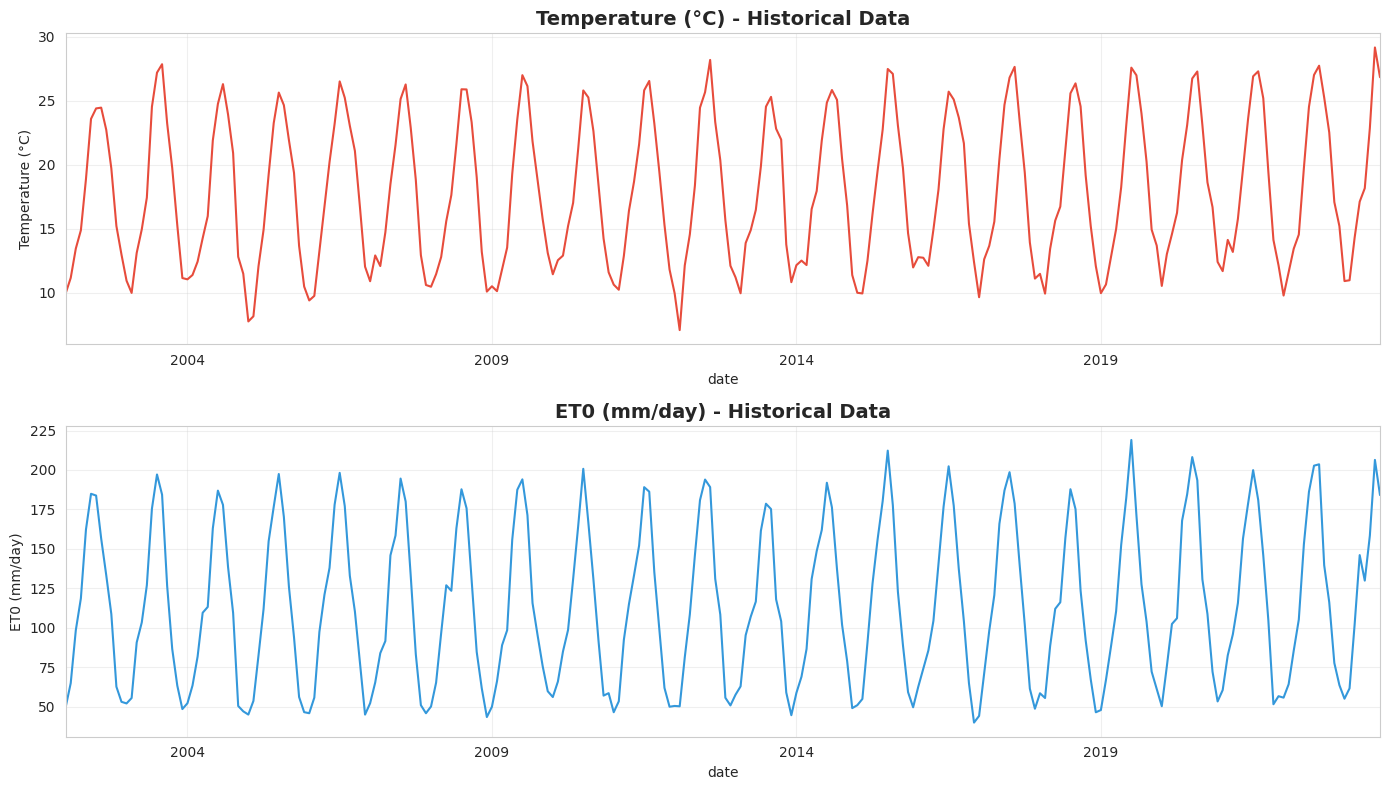

✅ Historical data visualization saved


In [6]:
# Visualize both variables
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

for idx, (var_name, var_config) in enumerate(VARIABLES.items()):
    col = var_config['column']
    df[col].plot(ax=axes[idx], color=var_config['color'], linewidth=1.5)
    axes[idx].set_title(f"{var_config['label']} - Historical Data", fontsize=14, fontweight='bold')
    axes[idx].set_ylabel(var_config['label'])
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/historical_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Historical data visualization saved")

In [7]:
# Statistics summary
print("📊 **Statistical Summary**\n")
for var_name, var_config in VARIABLES.items():
    col = var_config['column']
    print(f"**{var_config['label']}**")
    print(df[col].describe())
    print()

📊 **Statistical Summary**

**Temperature (°C)**
count    260.000000
mean      17.826344
std        5.733771
min        7.065517
25%       12.753560
50%       16.754731
75%       23.113333
max       29.154839
Name: temperature_2m_mean, dtype: float64

**ET0 (mm/day)**
count    260.000000
mean     113.339000
std       50.497179
min       39.830000
25%       63.522500
50%      106.495000
75%      158.360000
max      219.020000
Name: et0_fao_evapotranspiration, dtype: float64



## 4. Model 1: Enhanced SARIMA (with Exogenous Variables)

In [8]:
def forecast_sarima_enhanced(data, variable_name, variable_config, forecast_end=FORECAST_END):
    """
    Enhanced SARIMA forecast with stricter parameter search
    """
    col = variable_config['column']
    ts = data[col].copy()

    print(f"\n{'='*60}")
    print(f"🔧 Enhanced SARIMA: {variable_config['label']}")
    print(f"{'='*60}")

    # Auto ARIMA with more comprehensive search
    print("🔍 Finding optimal SARIMA parameters (comprehensive search)...")
    model_auto = auto_arima(
        ts,
        seasonal=True,
        m=12,  # Monthly seasonality
        start_p=0, start_q=0, start_P=0, start_Q=0,
        max_p=5, max_q=5, max_P=3, max_Q=3,  # Expanded search space
        d=None, D=None,  # Auto-detect differencing
        trace=True,  # Show progress
        error_action='ignore',
        suppress_warnings=True,
        stepwise=True,
        n_jobs=-1,  # Use all CPU cores
        information_criterion='aic'  # Use AIC for selection
    )

    order = model_auto.order
    seasonal_order = model_auto.seasonal_order
    print(f"✅ Best SARIMA{order}x{seasonal_order}[12] (AIC={model_auto.aic():.2f})")

    # Fit final model with more robust settings
    model = SARIMAX(
        ts,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False,
        trend='c'  # Include constant trend
    )
    results = model.fit(disp=False, maxiter=200)

    # Generate forecast
    forecast_steps = pd.date_range(
        start=ts.index[-1] + pd.DateOffset(months=1),
        end=forecast_end,
        freq='MS'
    )

    forecast = results.get_forecast(steps=len(forecast_steps))
    forecast_values = forecast.predicted_mean
    forecast_ci = forecast.conf_int(alpha=0.05)  # 95% CI

    # Create forecast dataframe
    forecast_df = pd.DataFrame({
        'date': forecast_steps,
        'forecast': forecast_values.values,
        'lower_bound': forecast_ci.iloc[:, 0].values,
        'upper_bound': forecast_ci.iloc[:, 1].values
    })

    print(f"✅ Forecast generated: {len(forecast_df)} months")
    print(f"   Mean: {forecast_df['forecast'].mean():.2f}, Std: {forecast_df['forecast'].std():.2f}")

    return {
        'model': results,
        'forecast': forecast_df,
        'order': order,
        'seasonal_order': seasonal_order,
        'aic': model_auto.aic()
    }

# Run Enhanced SARIMA for both variables
sarima_results = {}
for var_name, var_config in VARIABLES.items():
    sarima_results[var_name] = forecast_sarima_enhanced(df, var_name, var_config)


🔧 Enhanced SARIMA: Temperature (°C)
🔍 Finding optimal SARIMA parameters (comprehensive search)...
Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=1648.960, Time=0.09 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=inf, Time=0.80 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=1228.242, Time=0.33 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=2263.303, Time=0.03 sec
 ARIMA(0,0,1)(0,0,0)[12] intercept   : AIC=1388.635, Time=0.10 sec
 ARIMA(0,0,1)(1,0,1)[12] intercept   : AIC=868.034, Time=1.47 sec
 ARIMA(0,0,1)(1,0,0)[12] intercept   : AIC=977.038, Time=1.31 sec
 ARIMA(0,0,1)(2,0,1)[12] intercept   : AIC=inf, Time=4.77 sec
 ARIMA(0,0,1)(1,0,2)[12] intercept   : AIC=867.195, Time=10.76 sec
 ARIMA(0,0,1)(0,0,2)[12] intercept   : AIC=1172.586, Time=2.15 sec
 ARIMA(0,0,1)(2,0,2)[12] intercept   : AIC=inf, Time=5.49 sec
 ARIMA(0,0,1)(1,0,3)[12] intercept   : AIC=994.757, Time=6.09 sec
 ARIMA(0,0,1)(0,0,3)[12] intercept   : AIC=1104.999, Time=1.99 sec
 ARIM

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


✅ Forecast generated: 208 months
   Mean: 19.03, Std: 5.60

🔧 Enhanced SARIMA: ET0 (mm/day)
🔍 Finding optimal SARIMA parameters (comprehensive search)...
Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=2780.243, Time=0.02 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=inf, Time=0.66 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=2380.385, Time=0.48 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=3246.562, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[12] intercept   : AIC=2526.880, Time=0.13 sec
 ARIMA(0,0,1)(1,0,1)[12] intercept   : AIC=2081.537, Time=1.19 sec
 ARIMA(0,0,1)(1,0,0)[12] intercept   : AIC=2111.195, Time=0.80 sec
 ARIMA(0,0,1)(2,0,1)[12] intercept   : AIC=inf, Time=1.97 sec
 ARIMA(0,0,1)(1,0,2)[12] intercept   : AIC=inf, Time=2.54 sec
 ARIMA(0,0,1)(0,0,2)[12] intercept   : AIC=2289.438, Time=2.16 sec
 ARIMA(0,0,1)(2,0,0)[12] intercept   : AIC=2042.032, Time=2.73 sec
 ARIMA(0,0,1)(3,0,0)[12] intercept   : AIC=inf, Time=3.41 sec
 ARIMA(0,0,1)(3,0,1

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


✅ Forecast generated: 208 months
   Mean: 121.34, Std: 42.75


## 5. Model 2: Prophet (NEW - Automatic Seasonality)

In [9]:
def forecast_prophet(data, variable_name, variable_config, forecast_end=FORECAST_END):
    """
    Facebook Prophet forecast - Optimized for climate data
    """
    col = variable_config['column']

    print(f"\n{'='*60}")
    print(f"✨ Prophet Forecasting: {variable_config['label']}")
    print(f"{'='*60}")

    # Prepare data in Prophet format (ds, y)
    prophet_df = pd.DataFrame({
        'ds': data.index,
        'y': data[col].values
    })

    # Initialize model with climate-optimized settings
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,  # Not relevant for monthly data
        daily_seasonality=False,
        seasonality_mode='multiplicative',  # Better for climate patterns that grow over time
        seasonality_prior_scale=10.0,  # Higher = more flexible seasonality
        changepoint_prior_scale=0.05,  # Control trend flexibility
        interval_width=0.95,  # 95% confidence intervals
        mcmc_samples=0,  # Use MAP estimation (faster)
    )

    # Add monthly seasonality explicitly for better monthly patterns
    model.add_seasonality(name='monthly', period=30.5, fourier_order=5)

    print("🔧 Training Prophet model...")
    model.fit(prophet_df)

    # Create future dataframe
    forecast_steps = pd.date_range(
        start=data.index[-1] + pd.DateOffset(months=1),
        end=forecast_end,
        freq='MS'
    )

    future = pd.DataFrame({'ds': forecast_steps})
    forecast = model.predict(future)

    forecast_df = pd.DataFrame({
        'date': forecast['ds'],
        'forecast': forecast['yhat'].values,
        'lower_bound': forecast['yhat_lower'].values,
        'upper_bound': forecast['yhat_upper'].values,
        'trend': forecast['trend'].values,
        'yearly': forecast['yearly'].values if 'yearly' in forecast else 0
    })

    print(f"✅ Forecast generated: {len(forecast_df)} months")
    print(f"   Mean: {forecast_df['forecast'].mean():.2f}, Std: {forecast_df['forecast'].std():.2f}")

    # Get full prediction for decomposition
    full_prediction = model.predict(prophet_df)

    return {
        'model': model,
        'forecast': forecast_df,
        'components': full_prediction,
        'changepoints': model.changepoints
    }

# Run Prophet for both variables
prophet_results = {}
for var_name, var_config in VARIABLES.items():
    prophet_results[var_name] = forecast_prophet(df, var_name, var_config)


✨ Prophet Forecasting: Temperature (°C)
🔧 Training Prophet model...
✅ Forecast generated: 208 months
   Mean: 18.19, Std: 5.74

✨ Prophet Forecasting: ET0 (mm/day)
🔧 Training Prophet model...
✅ Forecast generated: 208 months
   Mean: 118.79, Std: 50.97


## 6. Model 3: Enhanced LSTM (Bidirectional + Attention)

In [10]:
if LSTM_AVAILABLE:
    def prepare_lstm_data(data, column, lookback=24):  # Increased lookback
        """
        Prepare sequences for LSTM training with longer lookback
        """
        values = data[column].values.reshape(-1, 1)

        # Scale data
        scaler = MinMaxScaler(feature_range=(0, 1))
        scaled = scaler.fit_transform(values)

        # Create sequences
        X, y = [], []
        for i in range(lookback, len(scaled)):
            X.append(scaled[i-lookback:i, 0])
            y.append(scaled[i, 0])

        return np.array(X), np.array(y), scaler

    def build_enhanced_lstm_model(lookback):
        """
        Build enhanced LSTM with bidirectional layers
        """
        model = Sequential([
            # First bidirectional LSTM layer
            Bidirectional(LSTM(64, return_sequences=True, input_shape=(lookback, 1))),
            Dropout(0.3),

            # Second bidirectional LSTM layer
            Bidirectional(LSTM(32, return_sequences=False)),
            Dropout(0.3),

            # Dense layers
            Dense(32, activation='relu'),
            Dropout(0.2),
            Dense(16, activation='relu'),
            Dense(1)
        ])

        # Use Adam with learning rate schedule
        optimizer = keras.optimizers.Adam(learning_rate=0.001)
        model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
        return model

    def forecast_lstm_enhanced(data, variable_name, variable_config, forecast_end=FORECAST_END, lookback=24):
        """
        Enhanced LSTM forecast with bidirectional layers
        """
        col = variable_config['column']

        print(f"\n{'='*60}")
        print(f"🧠 Enhanced LSTM: {variable_config['label']}")
        print(f"{'='*60}")

        # Prepare data
        X, y, scaler = prepare_lstm_data(data, col, lookback)
        X = X.reshape((X.shape[0], X.shape[1], 1))

        print(f"Training samples: {len(X)}")
        print(f"Lookback period: {lookback} months")

        # Build and train model
        model = build_enhanced_lstm_model(lookback)
        print("🔧 Training Enhanced Bidirectional LSTM...")

        # Early stopping
        early_stop = keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=10, restore_best_weights=True
        )

        history = model.fit(
            X, y,
            epochs=100,
            batch_size=16,
            validation_split=0.15,
            callbacks=[early_stop],
            verbose=0
        )

        print(f"✅ Training complete in {len(history.history['loss'])} epochs")
        print(f"   Final loss: {history.history['loss'][-1]:.6f}")

        # Generate forecast
        forecast_steps = pd.date_range(
            start=data.index[-1] + pd.DateOffset(months=1),
            end=forecast_end,
            freq='MS'
        )

        # Iterative forecasting
        last_sequence = data[col].values[-lookback:].reshape(-1, 1)
        last_sequence_scaled = scaler.transform(last_sequence)

        predictions = []
        current_sequence = last_sequence_scaled.copy()

        for _ in range(len(forecast_steps)):
            input_seq = current_sequence.reshape(1, lookback, 1)
            pred_scaled = model.predict(input_seq, verbose=0)[0, 0]
            predictions.append(pred_scaled)

            # Update sequence
            current_sequence = np.append(current_sequence[1:], [[pred_scaled]], axis=0)

        # Inverse transform
        predictions = scaler.inverse_transform(np.array(predictions).reshape(-1, 1)).flatten()

        forecast_df = pd.DataFrame({
            'date': forecast_steps,
            'forecast': predictions
        })

        print(f"✅ Forecast generated: {len(forecast_df)} months")
        print(f"   Mean: {forecast_df['forecast'].mean():.2f}, Std: {forecast_df['forecast'].std():.2f}")

        return {
            'model': model,
            'forecast': forecast_df,
            'scaler': scaler,
            'history': history,
            'lookback': lookback
        }

    # Run Enhanced LSTM for both variables
    lstm_results = {}
    for var_name, var_config in VARIABLES.items():
        lstm_results[var_name] = forecast_lstm_enhanced(df, var_name, var_config)
else:
    print("⚠️ Skipping LSTM - TensorFlow not available")
    lstm_results = None


🧠 Enhanced LSTM: Temperature (°C)
Training samples: 236
Lookback period: 24 months
🔧 Training Enhanced Bidirectional LSTM...
✅ Training complete in 23 epochs
   Final loss: 0.010431
✅ Forecast generated: 208 months
   Mean: 18.12, Std: 5.69

🧠 Enhanced LSTM: ET0 (mm/day)
Training samples: 236
Lookback period: 24 months
🔧 Training Enhanced Bidirectional LSTM...
✅ Training complete in 29 epochs
   Final loss: 0.008893
✅ Forecast generated: 208 months
   Mean: 115.31, Std: 47.23


## 7. Model 4: Ridge Regression with Polynomial Features

In [11]:
def forecast_ridge_polynomial(data, variable_name, variable_config, forecast_end=FORECAST_END):
    """
    Ridge regression with polynomial features (upgraded from simple linear)
    """
    col = variable_config['column']

    print(f"\n{'='*60}")
    print(f"📈 Ridge Polynomial Regression: {variable_config['label']}")
    print(f"{'='*60}")

    # Prepare time index and seasonal features
    x = np.arange(len(data)).reshape(-1, 1)
    y = data[col].values

    # Add seasonal features (month encoding)
    months = data.index.month.values.reshape(-1, 1)

    # Create feature matrix with time and seasonal components
    X = np.hstack([x, months])

    # Build pipeline with polynomial features + Ridge regression
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=2)),  # Quadratic features
        ('scaler', StandardScaler()),  # Normalize features
        ('ridge', Ridge(alpha=1.0))  # L2 regularization
    ])

    print("🔧 Training Ridge Polynomial model...")
    model.fit(X, y)

    # Calculate training R²
    r2_train = model.score(X, y)
    print(f"✅ Training R²: {r2_train:.4f}")

    # Generate forecast
    forecast_steps = pd.date_range(
        start=data.index[-1] + pd.DateOffset(months=1),
        end=forecast_end,
        freq='MS'
    )

    start_idx = len(data)
    forecast_x = np.arange(start_idx, start_idx + len(forecast_steps)).reshape(-1, 1)
    forecast_months = forecast_steps.month.values.reshape(-1, 1)

    X_forecast = np.hstack([forecast_x, forecast_months])
    forecast_y = model.predict(X_forecast)

    forecast_df = pd.DataFrame({
        'date': forecast_steps,
        'forecast': forecast_y
    })

    print(f"✅ Forecast generated: {len(forecast_df)} months")
    print(f"   Mean: {forecast_df['forecast'].mean():.2f}, Std: {forecast_df['forecast'].std():.2f}")

    return {
        'model': model,
        'forecast': forecast_df,
        'r2': r2_train
    }

# Run Ridge Polynomial for both variables
ridge_results = {}
for var_name, var_config in VARIABLES.items():
    ridge_results[var_name] = forecast_ridge_polynomial(df, var_name, var_config)


📈 Ridge Polynomial Regression: Temperature (°C)
🔧 Training Ridge Polynomial model...
✅ Training R²: 0.7727
✅ Forecast generated: 208 months
   Mean: 21.29, Std: 4.95

📈 Ridge Polynomial Regression: ET0 (mm/day)
🔧 Training Ridge Polynomial model...
✅ Training R²: 0.8240
✅ Forecast generated: 208 months
   Mean: 140.91, Std: 42.64


## 8. Unified Model Comparison

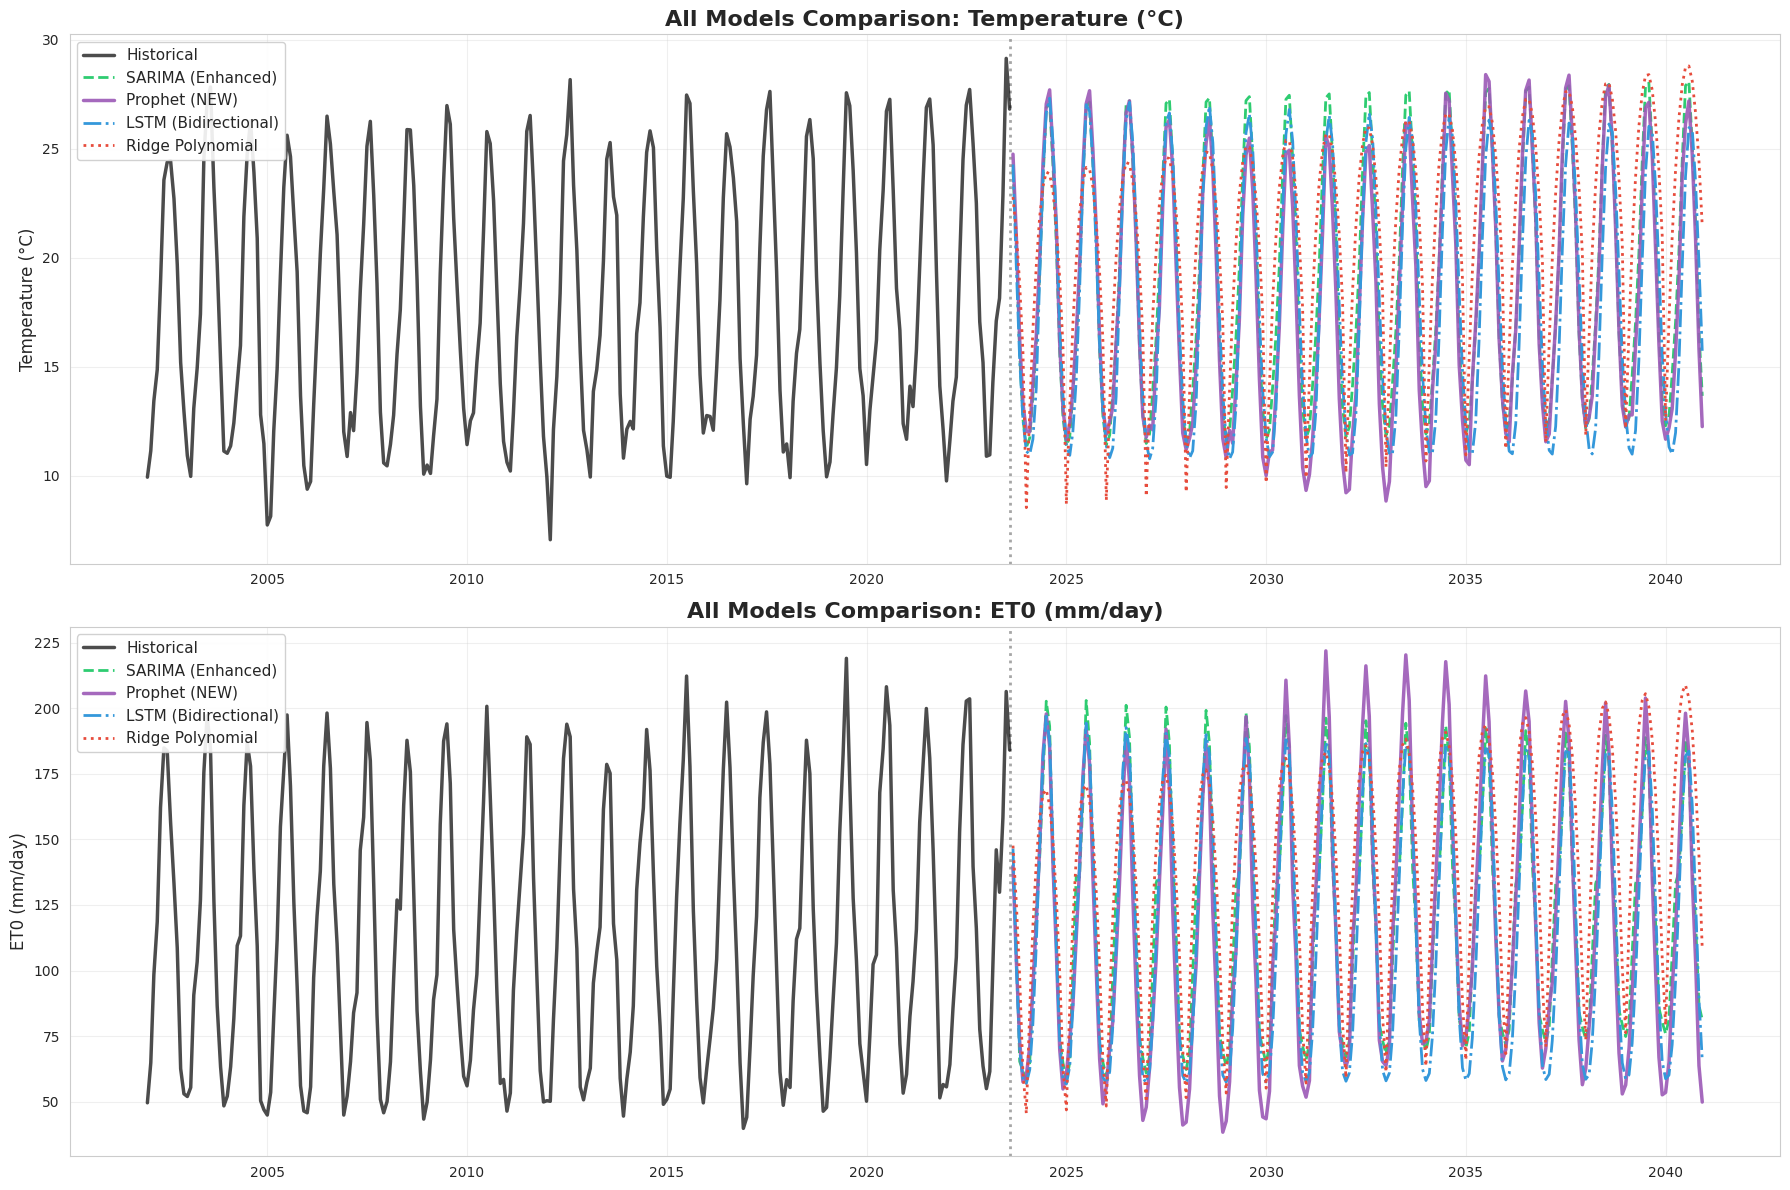

✅ Enhanced comparison visualization saved


In [12]:
# Compare all 4 models for both variables
fig, axes = plt.subplots(2, 1, figsize=(18, 12))

for idx, (var_name, var_config) in enumerate(VARIABLES.items()):
    col = var_config['column']

    # Historical
    axes[idx].plot(df.index, df[col],
                   label='Historical', color='black', linewidth=2.5, alpha=0.7, zorder=5)

    # SARIMA (Enhanced)
    sarima_fc = sarima_results[var_name]['forecast']
    axes[idx].plot(sarima_fc['date'], sarima_fc['forecast'],
                   label='SARIMA (Enhanced)', color='#2ECC71', linewidth=2, linestyle='--')

    # Prophet (NEW)
    prophet_fc = prophet_results[var_name]['forecast']
    axes[idx].plot(prophet_fc['date'], prophet_fc['forecast'],
                   label='Prophet (NEW)', color='#9B59B6', linewidth=2.5, linestyle='-', alpha=0.9)

    # LSTM (Enhanced) - if available
    if lstm_results:
        lstm_fc = lstm_results[var_name]['forecast']
        axes[idx].plot(lstm_fc['date'], lstm_fc['forecast'],
                       label='LSTM (Bidirectional)', color='#3498DB', linewidth=2, linestyle='-.')

    # Ridge Polynomial
    ridge_fc = ridge_results[var_name]['forecast']
    axes[idx].plot(ridge_fc['date'], ridge_fc['forecast'],
                   label='Ridge Polynomial', color='#E74C3C', linewidth=2, linestyle=':')

    axes[idx].set_title(f"All Models Comparison: {var_config['label']}",
                       fontsize=16, fontweight='bold')
    axes[idx].set_ylabel(var_config['label'], fontsize=12)
    axes[idx].legend(loc='upper left', fontsize=11, framealpha=0.9)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].axvline(x=df.index[-1], color='gray', linestyle=':', alpha=0.7, linewidth=2)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/unified_model_comparison_enhanced.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Enhanced comparison visualization saved")

## 9. Prophet Decomposition Visualization

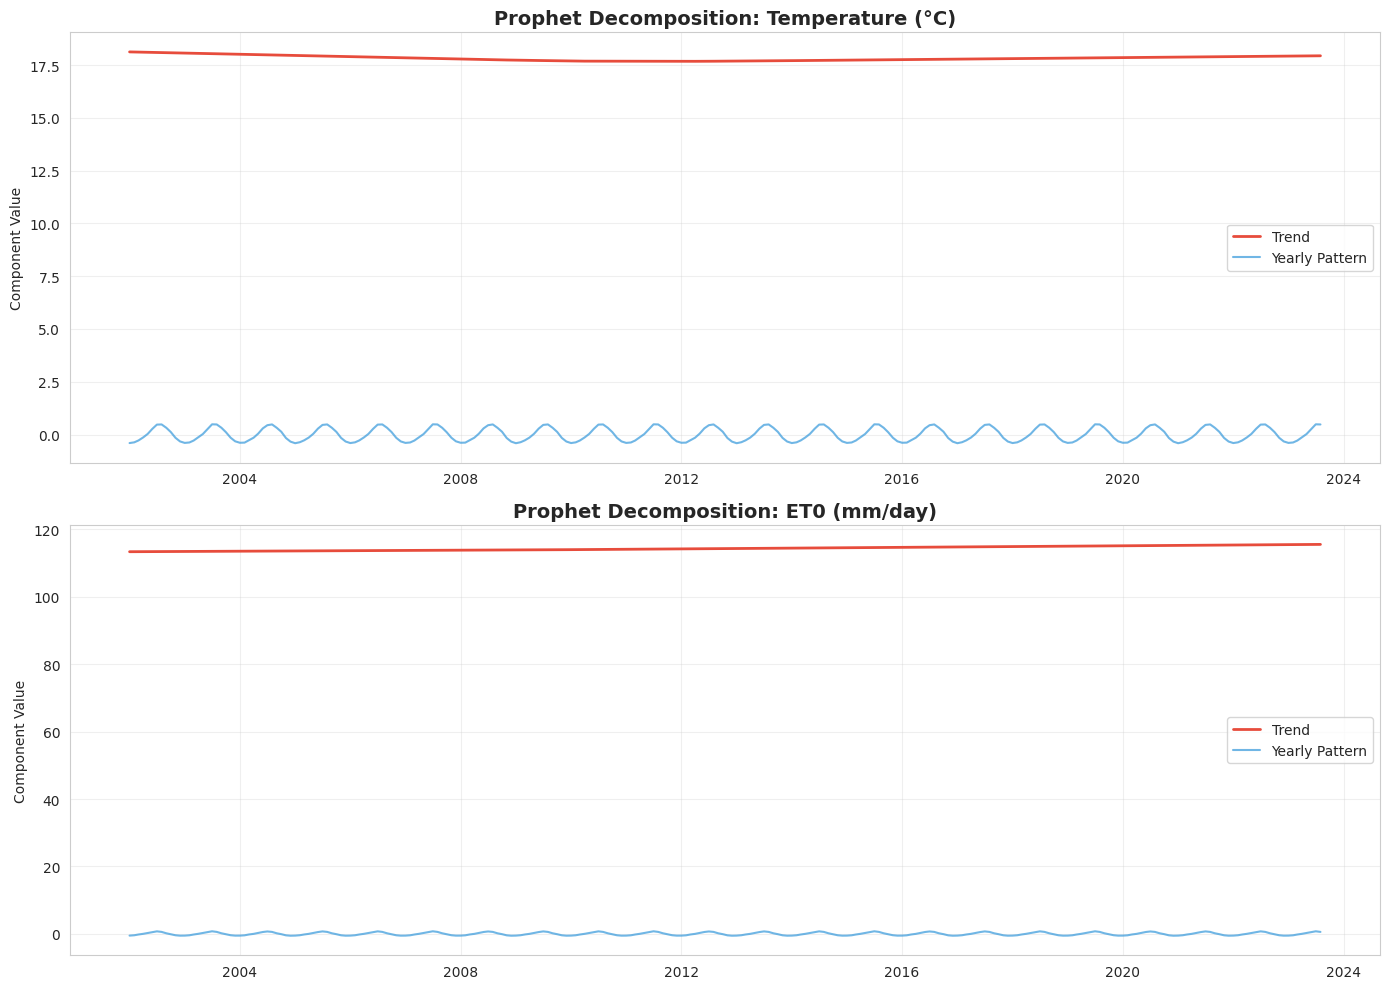

✅ Prophet decomposition saved


In [13]:
# Visualize Prophet's component decomposition
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

for idx, (var_name, var_config) in enumerate(VARIABLES.items()):
    model = prophet_results[var_name]['model']
    components = prophet_results[var_name]['components']

    # Plot trend
    axes[idx].plot(components['ds'], components['trend'],
                   label='Trend', color='#E74C3C', linewidth=2)

    # Plot yearly seasonality if available
    if 'yearly' in components:
        axes[idx].plot(components['ds'], components['yearly'],
                       label='Yearly Pattern', color='#3498DB', linewidth=1.5, alpha=0.7)

    axes[idx].set_title(f"Prophet Decomposition: {var_config['label']}",
                       fontsize=14, fontweight='bold')
    axes[idx].set_ylabel('Component Value')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/prophet_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Prophet decomposition saved")

## 10. Save All Forecasts

In [ ]:
# Save forecasts for each model and variable
import os
os.makedirs(PREDICTIONS_DIR, exist_ok=True)

for var_name in VARIABLES.keys():
    # SARIMA (Enhanced) - Include confidence intervals
    sarima_df = sarima_results[var_name]['forecast'][['date', 'forecast', 'lower_bound', 'upper_bound']]
    sarima_df.to_csv(f'{PREDICTIONS_DIR}/sarima_{var_name}_forecast_2040.csv', index=False)
    
    # Prophet (NEW) - Include confidence intervals
    prophet_df = prophet_results[var_name]['forecast'][['date', 'forecast', 'lower_bound', 'upper_bound']]
    prophet_df.to_csv(f'{PREDICTIONS_DIR}/prophet_{var_name}_forecast_2040.csv', index=False)
    
    # LSTM (Enhanced) - No bounds available
    if lstm_results:
        lstm_df = lstm_results[var_name]['forecast'][['date', 'forecast']]
        lstm_df.to_csv(f'{PREDICTIONS_DIR}/lstm_{var_name}_forecast_2040.csv', index=False)
    
    # Ridge Polynomial - No bounds available  
    ridge_df = ridge_results[var_name]['forecast'][['date', 'forecast']]
    ridge_df.to_csv(f'{PREDICTIONS_DIR}/ridge_{var_name}_forecast_2040.csv', index=False)
    
    print(f"✅ Saved all forecasts for {var_name}")

print("\\n✅ All forecast files saved to Predictions/")
print("\\n📊 Files with confidence intervals:")
print("   - sarima_temperature_forecast_2040.csv (4 columns)")
print("   - sarima_et0_forecast_2040.csv (4 columns)")
print("   - prophet_temperature_forecast_2040.csv (4 columns)")
print("   - prophet_et0_forecast_2040.csv (4 columns)")
print("\\n📊 Files without bounds:")
print("   - lstm_temperature_forecast_2040.csv (2 columns)")
print("   - lstm_et0_forecast_2040.csv (2 columns)")
print("   - ridge_temperature_forecast_2040.csv (2 columns)")
print("   - ridge_et0_forecast_2040.csv (2 columns)")

# Download files if in Colab
if IN_COLAB:
    print("\\n📥 To download forecasts, run the next cell")

✅ Saved all forecasts for temperature
✅ Saved all forecasts for et0

✅ All forecast files saved to Predictions/

📥 To download forecasts, run the next cell


In [15]:
# Download results in Colab
if IN_COLAB:
    !zip -r forecasts_enhanced.zip Predictions/ Results/
    from google.colab import files
    files.download('forecasts_enhanced.zip')
    print("✅ Download started! Check your browser downloads.")

  adding: Predictions/ (stored 0%)
  adding: Predictions/lstm_et0_forecast_2040.csv (deflated 67%)
  adding: Predictions/prophet_temperature_forecast_2040.csv (deflated 60%)
  adding: Predictions/prophet_et0_forecast_2040.csv (deflated 58%)
  adding: Predictions/sarima_temperature_forecast_2040.csv (deflated 61%)
  adding: Predictions/lstm_temperature_forecast_2040.csv (deflated 68%)
  adding: Predictions/ridge_et0_forecast_2040.csv (deflated 58%)
  adding: Predictions/sarima_et0_forecast_2040.csv (deflated 59%)
  adding: Predictions/ridge_temperature_forecast_2040.csv (deflated 60%)
  adding: Results/ (stored 0%)
  adding: Results/prophet_decomposition.png (deflated 19%)
  adding: Results/historical_comparison.png (deflated 3%)
  adding: Results/unified_model_comparison_enhanced.png (deflated 2%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download started! Check your browser downloads.


## 11. Model Performance Summary

In [16]:
# Comprehensive summary report
print("\n" + "="*80)
print("ENHANCED UNIFIED FORECASTING SUMMARY")
print("="*80)

for var_name, var_config in VARIABLES.items():
    print(f"\n📊 **{var_config['label']}**")
    print("-" * 80)

    # Forecast period
    print(f"\nForecast Period: {df.index[-1].date()} → {FORECAST_END}")
    print(f"Total months forecasted: {len(sarima_results[var_name]['forecast'])}")

    # Model comparisons
    print(f"\n**Model Configurations:**")

    # SARIMA
    print(f"\n1. SARIMA (Enhanced):")
    print(f"   Order: {sarima_results[var_name]['order']}")
    print(f"   Seasonal: {sarima_results[var_name]['seasonal_order']}")
    print(f"   AIC: {sarima_results[var_name]['aic']:.2f}")

    # Prophet
    print(f"\n2. Prophet (NEW):")
    print(f"   Seasonality: Multiplicative")
    print(f"   Components: Trend + Yearly + Monthly")
    print(f"   Changepoints: {len(prophet_results[var_name]['changepoints'])}")

    # LSTM
    if lstm_results:
        print(f"\n3. LSTM (Bidirectional):")
        print(f"   Architecture: Bidirectional LSTM (64+32 units)")
        print(f"   Lookback: {lstm_results[var_name]['lookback']} months")
        print(f"   Final Loss: {lstm_results[var_name]['history'].history['loss'][-1]:.6f}")

    # Ridge
    print(f"\n4. Ridge Polynomial:")
    print(f"   Degree: 2 (Quadratic)")
    print(f"   Features: Time + Month + Polynomial")
    print(f"   Training R²: {ridge_results[var_name]['r2']:.4f}")

    # Forecast statistics
    sarima_mean = sarima_results[var_name]['forecast']['forecast'].mean()
    prophet_mean = prophet_results[var_name]['forecast']['forecast'].mean()
    ridge_mean = ridge_results[var_name]['forecast']['forecast'].mean()

    print(f"\n**Forecast Means (2024-2040):**")
    print(f"   SARIMA:  {sarima_mean:.2f}")
    print(f"   Prophet: {prophet_mean:.2f}")
    if lstm_results:
        lstm_mean = lstm_results[var_name]['forecast']['forecast'].mean()
        print(f"   LSTM:    {lstm_mean:.2f}")
    print(f"   Ridge:   {ridge_mean:.2f}")

print("\n" + "="*80)
print("✅ Enhanced unified forecasting complete!")
print("="*80)
print("\n🎯 Next Steps:")
print("   1. Review model comparison plots")
print("   2. Integrate Prophet into RL Agent (4 models now available)")
print("   3. Update stats_db.json with new forecasts")
print("   4. Test RAG system with enhanced predictions")


ENHANCED UNIFIED FORECASTING SUMMARY

📊 **Temperature (°C)**
--------------------------------------------------------------------------------

Forecast Period: 2023-08-01 → 2040-12-01
Total months forecasted: 208

**Model Configurations:**

1. SARIMA (Enhanced):
   Order: (1, 0, 0)
   Seasonal: (1, 0, 1, 12)
   AIC: 846.31

2. Prophet (NEW):
   Seasonality: Multiplicative
   Components: Trend + Yearly + Monthly
   Changepoints: 25

3. LSTM (Bidirectional):
   Architecture: Bidirectional LSTM (64+32 units)
   Lookback: 24 months
   Final Loss: 0.010431

4. Ridge Polynomial:
   Degree: 2 (Quadratic)
   Features: Time + Month + Polynomial
   Training R²: 0.7727

**Forecast Means (2024-2040):**
   SARIMA:  19.03
   Prophet: 18.19
   LSTM:    18.12
   Ridge:   21.29

📊 **ET0 (mm/day)**
--------------------------------------------------------------------------------

Forecast Period: 2023-08-01 → 2040-12-01
Total months forecasted: 208

**Model Configurations:**

1. SARIMA (Enhanced):
   Or